In [51]:
from free_fermion_methods_cov import *
import matplotlib.pyplot as plt

In [79]:
L = 10
alphas = [0.1, 0.5, 2, 3, 10]

state = random_FGS(L)

# Generate all possible binary arrays of length 2*L
all_binary_arrays = itertools.product([0, 1], repeat=2*L)

# Filter out arrays where the number of 1s is not even
even_ones_arrays = (arr for arr in all_binary_arrays if arr.count(1) % 2 == 0 and arr.count(1) > 0)


results = [[] for ii in range(L)]

for majoranas in even_ones_arrays:
    ii = (majoranas.count(1)) // 2 - 1
    results[ii].append(state.compute_exp_val_Majorana_string(np.array(majoranas))**2)

results_summed = np.zeros((L, len(alphas)))
for ii in range(L):
    for jj, alpha in enumerate(alphas):
        results_summed[ii,jj] = np.sum(np.array(results[ii])**(alpha))
    

# if alpha == 1:
#     return -np.sum(results*np.log2(results)) / 2**L
# elif alpha == 0:
#     raise ValueError('Not implemented for alpha 0')
# elif alpha == np.inf:
#     raise ValueError('Not implemented for alpha infinity')
# else:
#     return np.log2(np.sum(results**(alpha))/2**L)/(1-alpha)

results_summed

array([[1.30451939e+02, 3.61675835e+01, 1.39262128e+00, 3.01686571e-01,
        1.53058242e-04],
       [2.68709150e+03, 3.56402005e+02, 1.63879053e+00, 1.11492385e-01,
        1.21430041e-07],
       [1.89561810e+04, 1.58610531e+03, 1.78376317e+00, 5.39437950e-02,
        4.79862159e-10],
       [5.74844379e+04, 3.71312608e+03, 1.86743823e+00, 3.60862002e-02,
        2.10482598e-11],
       [8.23985988e+04, 4.89568730e+03, 1.89423697e+00, 3.15101798e-02,
        9.22260420e-12],
       [5.74844379e+04, 3.71312608e+03, 1.86743823e+00, 3.60862002e-02,
        2.10482598e-11],
       [1.89561810e+04, 1.58610531e+03, 1.78376317e+00, 5.39437950e-02,
        4.79862159e-10],
       [2.68709150e+03, 3.56402005e+02, 1.63879053e+00, 1.11492385e-01,
        1.21430041e-07],
       [1.30451939e+02, 3.61675835e+01, 1.39262128e+00, 3.01686571e-01,
        1.53058242e-04],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00]])

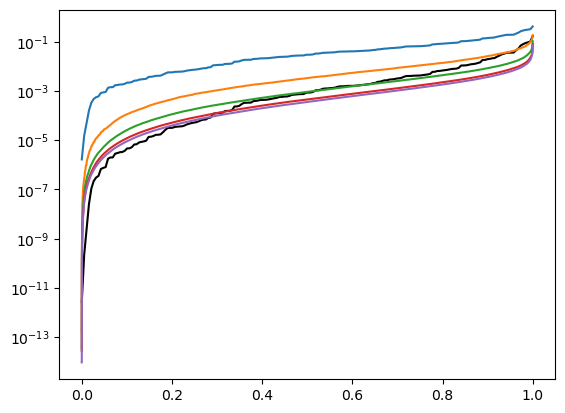

In [91]:
plt.plot(np.linspace(0, 1, len(results[0])), np.sort(results[0])**2, color = 'k')
for ii in range(L//2):
    plt.plot(np.linspace(0, 1, len(results[ii])), np.sort(results[ii]))
plt.yscale('log')

In [ ]:
plt.p

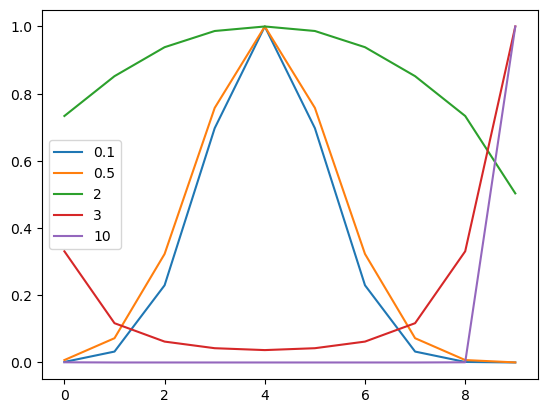

In [76]:
for jj, alpha in enumerate(alphas):
    plt.plot(results_summed[:, jj]/np.max(results_summed[:, jj]), label = alpha)

plt.legend()


In [16]:
2.09062135**4/4

4.775749441202255

In [22]:
results_summed

array([ 8., 28., 56., 70., 56., 28.,  8.,  1.])

In [92]:
from scipy.linalg import expm

def generate_ising_state(n, g, pbc = True):
    '''
    XX + g*Z
    '''
    h = np.zeros((2*n, 2*n), float)
    for ii in range(n-1):
        h[2 * ii, 2 * ii + 1] = g
        h[2 * ii + 1, 2 * ii + 2] = 1
    h[2*n-2, 2*n-1] = 1
    
    if pbc:
        h[2*n-1, 0] = 1
    
    h = h - h.T
    return h


def evolution_operator(h, t):
    return expm(4*h*t)



L = 8
alpha = 2
t = 1

O = evolution_operator(generate_ising_state(L, 2), t)

state = product_0_FGS(L)


state.apply_U_global(O)



# Generate all possible binary arrays of length 2*L
all_binary_arrays = itertools.product([0, 1], repeat=2*L)

# Filter out arrays where the number of 1s is not even
even_ones_arrays = (arr for arr in all_binary_arrays if arr.count(1) % 2 == 0 and arr.count(1) > 0)


results = [[] for ii in range(L)]

for majoranas in even_ones_arrays:
    ii = (majoranas.count(1)) // 2 - 1
    results[ii].append(state.compute_exp_val_Majorana_string(np.array(majoranas))**2)

results_summed = np.zeros((L, len(alphas)))
for ii in range(L):
    for jj, alpha in enumerate(alphas):
        results_summed[ii,jj] = np.sum(np.array(results[ii])**(alpha))
    

    

# if alpha == 1:
#     return -np.sum(results*np.log2(results)) / 2**L
# elif alpha == 0:
#     raise ValueError('Not implemented for alpha 0')
# elif alpha == np.inf:
#     raise ValueError('Not implemented for alpha infinity')
# else:
#     return np.log2(np.sum(results**(alpha))/2**L)/(1-alpha)

results_summed

array([[7.74737907e+01, 2.02760479e+01, 3.86843261e+00, 2.54382708e+00,
        1.92797335e-01],
       [9.56859100e+02, 1.26352178e+02, 8.17398627e+00, 4.07780833e+00,
        7.03431756e-02],
       [3.78895541e+03, 3.49290270e+02, 1.21413628e+01, 5.18234646e+00,
        4.94281034e-02],
       [5.80130580e+03, 4.82918374e+02, 1.37582573e+01, 5.58858463e+00,
        4.23944537e-02],
       [3.78895541e+03, 3.49290270e+02, 1.21413628e+01, 5.18234646e+00,
        4.94281034e-02],
       [9.56859100e+02, 1.26352178e+02, 8.17398627e+00, 4.07780833e+00,
        7.03431756e-02],
       [7.74737907e+01, 2.02760479e+01, 3.86843261e+00, 2.54382708e+00,
        1.92797335e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00]])

In [48]:
from scipy.special import binom

binomial = np.array([binom(L, ii+1) for ii in range(L)])
binom(8,2)
print(binomial)

[ 8. 28. 56. 70. 56. 28.  8.  1.]


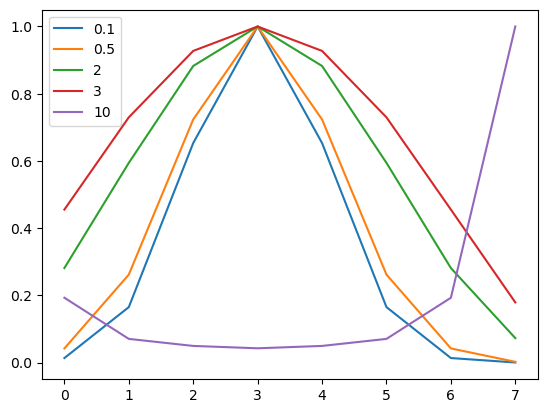

In [78]:
for jj, alpha in enumerate(alphas):
    plt.plot(results_summed[:, jj]/np.max(results_summed[:, jj]), label = alpha)

plt.legend()


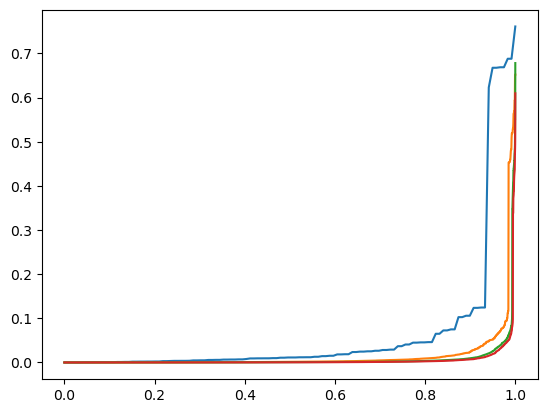

In [95]:
# plt.plot(np.linspace(0, 1, len(results[0])), np.sort(results[0])**2, color = 'k')
for ii in range(L//2):
    plt.plot(np.linspace(0, 1, len(results[ii])), np.sort(results[ii]))
# plt.yscale('log')